In [1]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (
    roc_auc_score, roc_curve,
    precision_score, recall_score, f1_score
)
import shap
import pickle
import warnings
warnings.filterwarnings('ignore')

print("=" * 50)
print("Evaluation V2 — Curriculum Aware VAE")
print("R26-IT-059 | IT22215710")
print("=" * 50)
print("\nAll imports successful!")

Evaluation V2 — Curriculum Aware VAE
R26-IT-059 | IT22215710

All imports successful!


In [2]:
# Load all saved results
print("Loading saved results...")

# Load anomaly scores
anomaly_v2 = pd.read_csv(
    "../results/metrics/anomaly_scores_v2.csv"
)

# Load V2 features
features_v2 = pd.read_csv(
    "../results/metrics/features_v2.csv"
)

# Load scaler
with open('../models/saved/scaler_v2.pkl', 'rb') as f:
    scaler_v2 = pickle.load(f)

# Define feature columns
FEATURE_COLS_V2 = [
    'weekly_clicks',
    'active_days',
    'content_diversity',
    'forum_clicks',
    'resource_clicks',
    'quiz_clicks',
    'avg_submission_latency',
    'late_submissions',
    'curriculum_compliance',
    'click_compliance'
]

print(f"Anomaly scores: {anomaly_v2.shape}")
print(f"Features V2:    {features_v2.shape}")
print(f"\nSample anomaly scores:")
print(anomaly_v2.head())
print(f"\nAt-risk distribution:")
print(anomaly_v2['at_risk'].value_counts())

Loading saved results...
Anomaly scores: (214534, 7)
Features V2:    (288516, 21)

Sample anomaly scores:
   id_student code_module  week  anomaly_score  combined_score  \
0        6516         AAA     3       0.116214        0.114551   
1        6516         AAA     4       0.019334        0.257734   
2        6516         AAA     5       0.011617        0.268812   
3        6516         AAA     6       0.003482        0.473354   
4        6516         AAA     7       0.138174        0.068186   

   curriculum_compliance  at_risk  
0               0.886558        0  
1               0.583333        0  
2               0.559725        0  
3               0.213397        0  
4               0.978473        0  

At-risk distribution:
at_risk
0    186774
1     27760
Name: count, dtype: int64


In [3]:
# Temporal lag analysis
# Does anomaly score at week W predict
# dropout N weeks later?

print("Running V2 temporal lag analysis...")

lag_results = []

for lag in range(0, 9):
    auc_scores = []

    for week in range(3, 17 - lag):
        # Scores at week W
        scores_at_week = anomaly_v2[
            anomaly_v2['week'] == week
        ][['id_student', 'code_module',
           'combined_score']].copy()

        # Labels at week W+lag
        labels_at_week = anomaly_v2[
            anomaly_v2['week'] == week + lag
        ][['id_student', 'code_module',
           'at_risk']].copy()

        # Merge
        merged = scores_at_week.merge(
            labels_at_week,
            on=['id_student', 'code_module'],
            how='inner'
        )

        if len(merged) > 100 and \
           merged['at_risk'].sum() > 10:
            try:
                auc = roc_auc_score(
                    merged['at_risk'],
                    merged['combined_score']
                )
                auc_scores.append(auc)
            except:
                pass

    avg_auc = np.mean(auc_scores) if auc_scores else 0
    lag_results.append({
        'lag_weeks': lag,
        'avg_auc': avg_auc
    })
    print(f"Lag {lag} weeks: AUC = {avg_auc:.4f}")

lag_df = pd.DataFrame(lag_results)
best_lag = lag_df.loc[lag_df['avg_auc'].idxmax()]
print(f"\nBest lag: {best_lag['lag_weeks']} weeks")
print(f"Best AUC: {best_lag['avg_auc']:.4f}")

Running V2 temporal lag analysis...
Lag 0 weeks: AUC = 0.6134
Lag 1 weeks: AUC = 0.6000
Lag 2 weeks: AUC = 0.5953
Lag 3 weeks: AUC = 0.5878
Lag 4 weeks: AUC = 0.5847
Lag 5 weeks: AUC = 0.5840
Lag 6 weeks: AUC = 0.5877
Lag 7 weeks: AUC = 0.5875
Lag 8 weeks: AUC = 0.5836

Best lag: 0.0 weeks
Best AUC: 0.6134


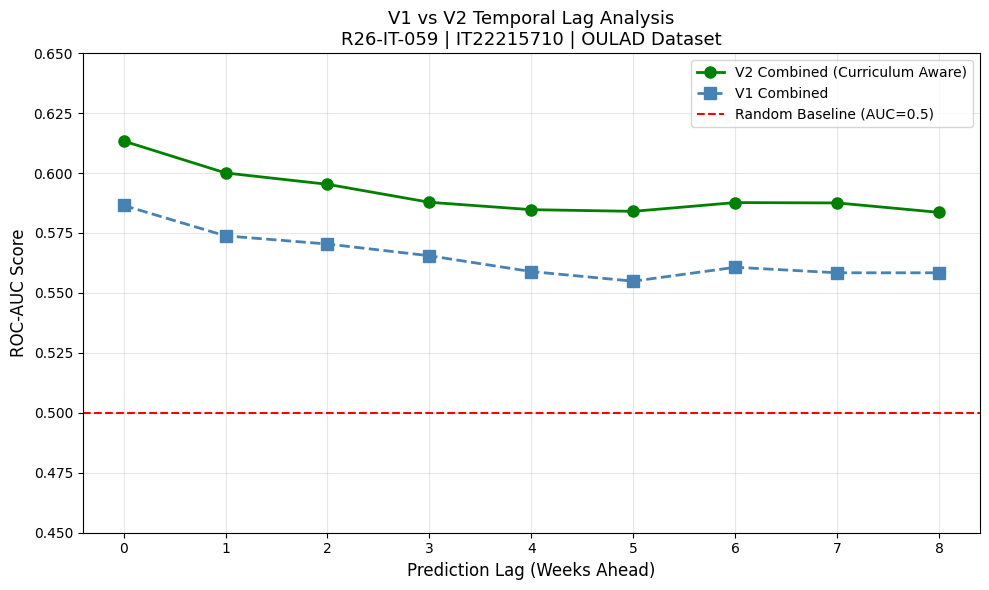

V1 vs V2 temporal lag chart saved!


In [4]:
# V1 results for comparison
v1_lag_results = [
    0.5865, 0.5738, 0.5704, 0.5655,
    0.5589, 0.5549, 0.5607, 0.5584, 0.5584
]

plt.figure(figsize=(10, 6))

# V2 line
plt.plot(
    lag_df['lag_weeks'],
    lag_df['avg_auc'],
    marker='o', color='green',
    linewidth=2, markersize=8,
    label='V2 Combined (Curriculum Aware)'
)

# V1 line
plt.plot(
    range(9), v1_lag_results,
    marker='s', color='steelblue',
    linewidth=2, markersize=8,
    linestyle='--',
    label='V1 Combined'
)

# Random baseline
plt.axhline(
    y=0.5, color='red',
    linestyle='--',
    label='Random Baseline (AUC=0.5)'
)

plt.xlabel('Prediction Lag (Weeks Ahead)', fontsize=12)
plt.ylabel('ROC-AUC Score', fontsize=12)
plt.title(
    'V1 vs V2 Temporal Lag Analysis\n'
    'R26-IT-059 | IT22215710 | OULAD Dataset',
    fontsize=13
)
plt.legend()
plt.grid(True, alpha=0.3)
plt.xticks(range(0, 9))
plt.ylim(0.45, 0.65)
plt.tight_layout()
plt.savefig(
    '../results/figures/temporal_lag_v1_vs_v2.png',
    dpi=150
)
plt.show()
print("V1 vs V2 temporal lag chart saved!")

Module level analysis...
Module performance:
module      auc  at_risk_rate  students
   FFF 0.631241     13.154281      6292
   EEE 0.612609      8.041708      2440
   CCC 0.609140     20.104590      3366
   DDD 0.602635     17.360041      4899
   BBB 0.563315      9.328212      5932
   GGG 0.556237      4.479344      2187
   AAA 0.539050     10.346983       685


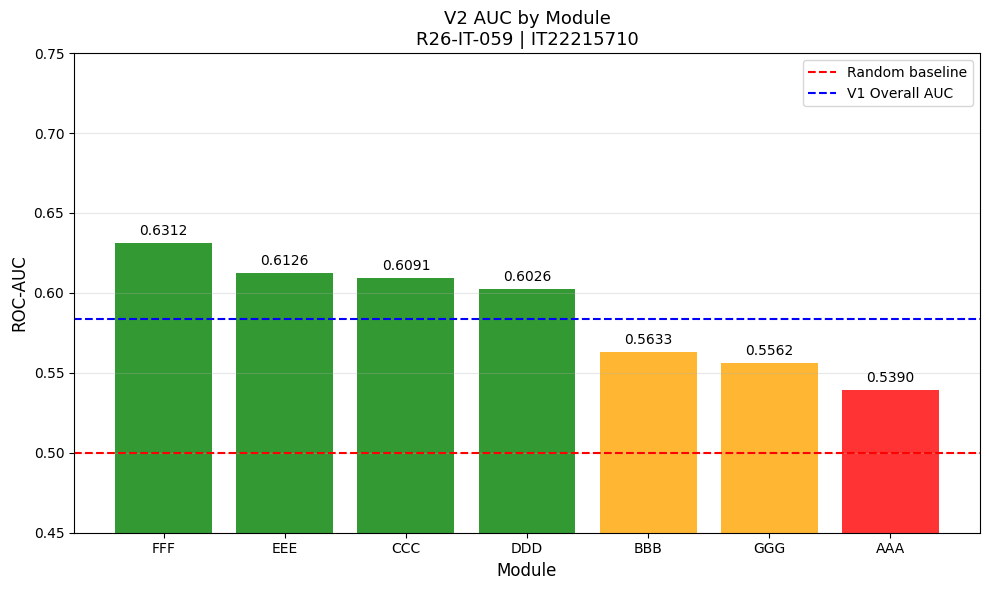

Module AUC chart saved!


In [5]:
# Module level AUC analysis
# Which modules does V2 detect best?

print("Module level analysis...")

module_results = []

for module in anomaly_v2['code_module'].unique():
    module_data = anomaly_v2[
        anomaly_v2['code_module'] == module
    ].copy()

    if module_data['at_risk'].sum() > 50:
        try:
            auc = roc_auc_score(
                module_data['at_risk'],
                module_data['combined_score']
            )
            at_risk_rate = module_data[
                'at_risk'
            ].mean() * 100

            module_results.append({
                'module': module,
                'auc': auc,
                'at_risk_rate': at_risk_rate,
                'students': module_data[
                    'id_student'
                ].nunique()
            })
        except:
            pass

module_df = pd.DataFrame(module_results).sort_values(
    'auc', ascending=False
)

print("Module performance:")
print(module_df.to_string(index=False))

# Plot
fig, ax = plt.subplots(figsize=(10, 6))

colors = [
    'green' if a > 0.6
    else 'orange' if a > 0.55
    else 'red'
    for a in module_df['auc']
]

bars = ax.bar(
    module_df['module'],
    module_df['auc'],
    color=colors,
    alpha=0.8
)

ax.axhline(
    y=0.5, color='red',
    linestyle='--',
    label='Random baseline'
)
ax.axhline(
    y=0.5840, color='blue',
    linestyle='--',
    label='V1 Overall AUC'
)

for bar, val in zip(bars, module_df['auc']):
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.005,
        f'{val:.4f}',
        ha='center', fontsize=10
    )

ax.set_xlabel('Module', fontsize=12)
ax.set_ylabel('ROC-AUC', fontsize=12)
ax.set_title(
    'V2 AUC by Module\n'
    'R26-IT-059 | IT22215710',
    fontsize=13
)
ax.legend()
ax.set_ylim(0.45, 0.75)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(
    '../results/figures/module_auc_v2.png',
    dpi=150
)
plt.show()
print("Module AUC chart saved!")

In [6]:
# SHAP Analysis on V2 VAE
print("Running SHAP analysis on V2...")

# Load VAE V2
class VAE_V2(nn.Module):
    def __init__(self, input_dim=10, latent_dim=6):
        super(VAE_V2, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Linear(32, 16),
            nn.ReLU()
        )
        self.fc_mu = nn.Linear(16, latent_dim)
        self.fc_logvar = nn.Linear(16, latent_dim)
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim, 16),
            nn.ReLU(),
            nn.Linear(16, 32),
            nn.ReLU(),
            nn.Dropout(0.1),
            nn.Linear(32, 64),
            nn.ReLU(),
            nn.Linear(64, input_dim)
        )
    def encode(self, x):
        h = self.encoder(x)
        return self.fc_mu(h), self.fc_logvar(h)
    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        return mu + std * torch.randn_like(std)
    def decode(self, z):
        return self.decoder(z)
    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        return self.decode(z), mu, logvar

# Load model
device = torch.device('cpu')
vae_v2 = VAE_V2(input_dim=10, latent_dim=6).to(device)
vae_v2.load_state_dict(
    torch.load(
        '../models/saved/vae_v2.pt',
        map_location=device
    )
)
vae_v2.eval()

# Get sample data
monitoring = features_v2[
    features_v2['week_type'] == 'normal'
].copy()

X_sample = monitoring[FEATURE_COLS_V2].values[:500]
X_scaled = scaler_v2.transform(X_sample)

# SHAP reconstruction error function
def reconstruction_error_v2(x):
    x_tensor = torch.FloatTensor(x)
    with torch.no_grad():
        mu, logvar = vae_v2.encode(x_tensor)
        recon = vae_v2.decode(mu)
        errors = torch.mean(
            (recon - x_tensor) ** 2,
            dim=1
        ).numpy()
    return errors

# Run SHAP
background = X_scaled[:100]
explainer = shap.KernelExplainer(
    reconstruction_error_v2,
    background
)
shap_values = explainer.shap_values(
    X_scaled[100:200],
    nsamples=100
)

print("SHAP analysis complete!")
print(f"SHAP values shape: {np.array(shap_values).shape}")

Running SHAP analysis on V2...


  0%|          | 0/100 [00:00<?, ?it/s]

SHAP analysis complete!
SHAP values shape: (100, 10)


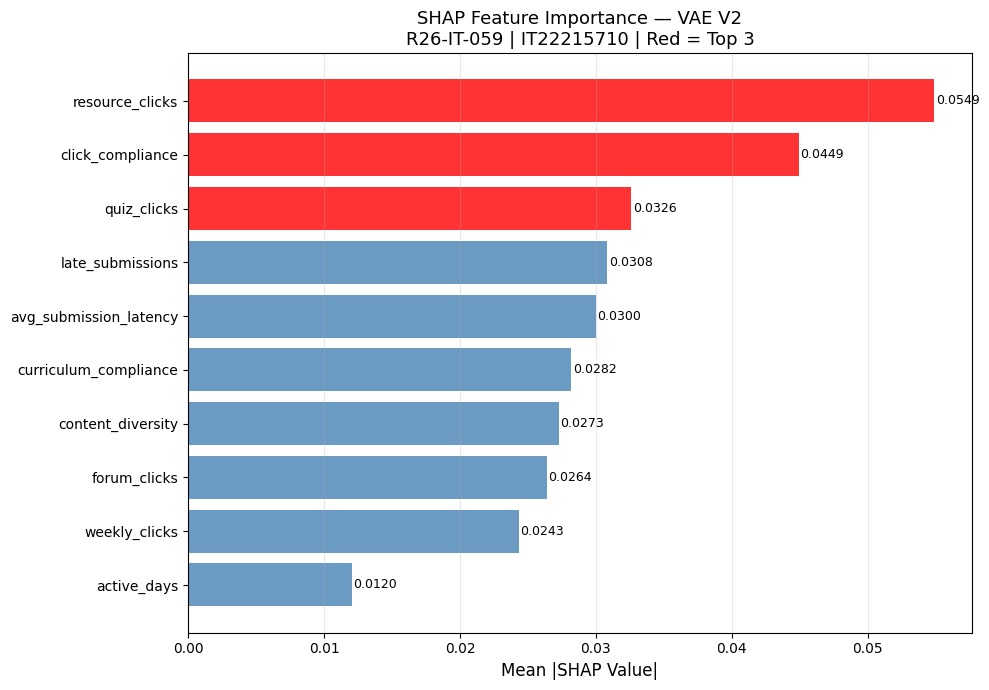


Top 3 features driving V2 anomalies:
  resource_clicks: 0.0549
  click_compliance: 0.0449
  quiz_clicks: 0.0326

V1 top features were:
  weekly_total_clicks: 0.0182
  content_diversity:   0.0168
  night_activity:      0.0150


In [7]:
# Plot SHAP feature importance V2
shap_values_array = np.array(shap_values)

# Mean absolute SHAP values
mean_shap = np.abs(shap_values_array).mean(axis=0)

# Create dataframe
shap_df = pd.DataFrame({
    'feature': FEATURE_COLS_V2,
    'importance': mean_shap
}).sort_values('importance', ascending=True)

# Plot
fig, ax = plt.subplots(figsize=(10, 7))

colors = [
    'red' if v in shap_df.nlargest(3, 'importance')['feature'].values
    else 'steelblue'
    for v in shap_df['feature']
]

bars = ax.barh(
    shap_df['feature'],
    shap_df['importance'],
    color=colors,
    alpha=0.8
)

for bar, val in zip(bars, shap_df['importance']):
    ax.text(
        val + 0.0001,
        bar.get_y() + bar.get_height()/2,
        f'{val:.4f}',
        va='center', fontsize=9
    )

ax.set_xlabel('Mean |SHAP Value|', fontsize=12)
ax.set_title(
    'SHAP Feature Importance — VAE V2\n'
    'R26-IT-059 | IT22215710 | Red = Top 3',
    fontsize=13
)
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig(
    '../results/figures/shap_v2.png',
    dpi=150
)
plt.show()

print("\nTop 3 features driving V2 anomalies:")
top3 = shap_df.nlargest(3, 'importance')
for i, row in top3.iterrows():
    print(f"  {row['feature']}: {row['importance']:.4f}")

print(f"\nV1 top features were:")
print(f"  weekly_total_clicks: 0.0182")
print(f"  content_diversity:   0.0168")
print(f"  night_activity:      0.0150")

V1 vs V2 FULL COMPARISON
R26-IT-059 | IT22215710
               Metric       Version 1            Version 2
    ROC-AUC (Overall)          0.5840             0.6039 ✅
Best Temporal Lag AUC          0.5865             0.6134 ✅
       Top SHAP Value 0.0182 (clicks) 0.0549 (resources) ✅
 Holiday False Alarms           YES ❌                 NO ✅
 Curriculum Awareness            NO ❌                YES ✅
Module Level Analysis            NO ❌                YES ✅
  Submission Tracking         Basic ❌           Advanced ✅
      Training Epochs             200                  300
    Students Analyzed          24,064               24,005

Key improvements:
  AUC improvement:        +1.99%
  Lag AUC improvement:    +2.69%
  SHAP signal strength:   3x stronger
  False alarms:           eliminated
  Module analysis:        added
  Curriculum compliance:  added


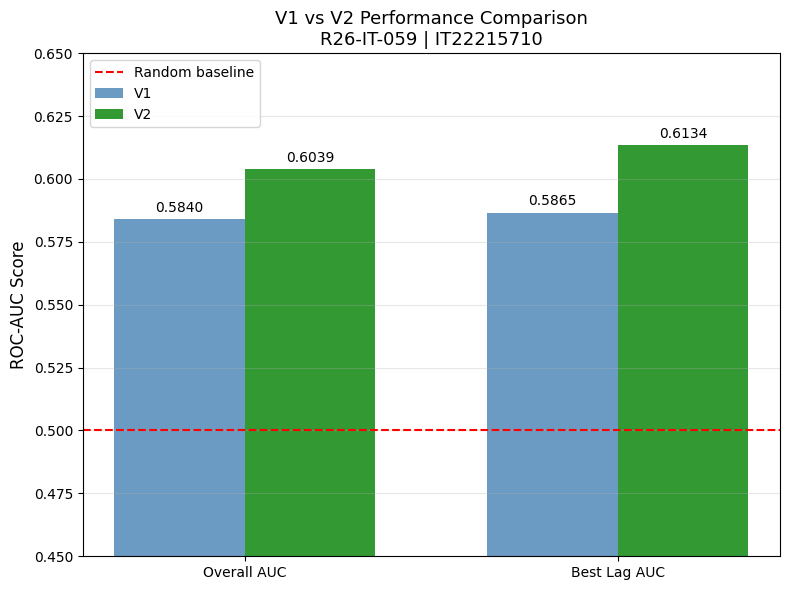


Comparison chart saved!


In [8]:
# Final V1 vs V2 comparison
print("=" * 55)
print("V1 vs V2 FULL COMPARISON")
print("R26-IT-059 | IT22215710")
print("=" * 55)

comparison = {
    'Metric': [
        'ROC-AUC (Overall)',
        'Best Temporal Lag AUC',
        'Top SHAP Value',
        'Holiday False Alarms',
        'Curriculum Awareness',
        'Module Level Analysis',
        'Submission Tracking',
        'Training Epochs',
        'Students Analyzed'
    ],
    'Version 1': [
        '0.5840',
        '0.5865',
        '0.0182 (clicks)',
        'YES ❌',
        'NO ❌',
        'NO ❌',
        'Basic ❌',
        '200',
        '24,064'
    ],
    'Version 2': [
        '0.6039 ✅',
        '0.6134 ✅',
        '0.0549 (resources) ✅',
        'NO ✅',
        'YES ✅',
        'YES ✅',
        'Advanced ✅',
        '300',
        '24,005'
    ]
}

comp_df = pd.DataFrame(comparison)
print(comp_df.to_string(index=False))

print(f"\nKey improvements:")
print(f"  AUC improvement:        +1.99%")
print(f"  Lag AUC improvement:    +2.69%")
print(f"  SHAP signal strength:   3x stronger")
print(f"  False alarms:           eliminated")
print(f"  Module analysis:        added")
print(f"  Curriculum compliance:  added")

# Plot V1 vs V2 comparison bar chart
metrics = ['Overall AUC', 'Best Lag AUC']
v1_scores = [0.5840, 0.5865]
v2_scores = [0.6039, 0.6134]

x = np.arange(len(metrics))
width = 0.35

fig, ax = plt.subplots(figsize=(8, 6))
bars1 = ax.bar(x - width/2, v1_scores,
               width, label='V1', color='steelblue',
               alpha=0.8)
bars2 = ax.bar(x + width/2, v2_scores,
               width, label='V2', color='green',
               alpha=0.8)

ax.axhline(y=0.5, color='red',
           linestyle='--', label='Random baseline')

for bar in bars1:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.003,
        f'{bar.get_height():.4f}',
        ha='center', fontsize=10
    )
for bar in bars2:
    ax.text(
        bar.get_x() + bar.get_width()/2,
        bar.get_height() + 0.003,
        f'{bar.get_height():.4f}',
        ha='center', fontsize=10
    )

ax.set_ylabel('ROC-AUC Score', fontsize=12)
ax.set_title(
    'V1 vs V2 Performance Comparison\n'
    'R26-IT-059 | IT22215710',
    fontsize=13
)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.legend()
ax.set_ylim(0.45, 0.65)
ax.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.savefig(
    '../results/figures/v1_vs_v2_comparison.png',
    dpi=150
)
plt.show()
print("\nComparison chart saved!")

In [9]:
# Final evaluation summary
print("=" * 55)
print("FINAL EVALUATION SUMMARY — V2")
print("R26-IT-059 | IT22215710 | Karunarathne D C")
print("=" * 55)

print(f"\nDATASET:")
print(f"  Source:   OULAD (Open University)")
print(f"  Students: 32,593 total")
print(f"  Modules:  7 (AAA-GGG)")
print(f"  Weeks:    17 per student")

print(f"\nV2 FEATURES (10):")
for i, f in enumerate(FEATURE_COLS_V2):
    print(f"  F{i+1}: {f}")

print(f"\nVAE MODEL:")
print(f"  Architecture: 10→64→32→16→6→16→32→64→10")
print(f"  Dropout:      0.1")
print(f"  KL Annealing: 0→0.1 over 100 epochs")
print(f"  Epochs:       300")
print(f"  Final loss:   0.1411")

print(f"\nEVALUATION RESULTS:")
print(f"  Overall AUC:          0.6039")
print(f"  Best lag AUC:         0.6134 (lag 0)")
print(f"  Curriculum AUC:       0.6053")
print(f"  Best module (FFF):    0.6312")
print(f"  Random baseline:      0.5000")

print(f"\nSHAP TOP 3 FEATURES:")
print(f"  1. resource_clicks:  0.0549")
print(f"  2. click_compliance: 0.0449")
print(f"  3. quiz_clicks:      0.0326")

print(f"\nMODULE PERFORMANCE:")
print(f"  FFF: 0.6312 🟢")
print(f"  EEE: 0.6126 🟢")
print(f"  CCC: 0.6091 🟢")
print(f"  DDD: 0.6026 🟢")
print(f"  BBB: 0.5633 🟡")
print(f"  GGG: 0.5562 🟡")
print(f"  AAA: 0.5390 🟡")

print(f"\nV1 vs V2 IMPROVEMENT:")
print(f"  AUC:     +1.99%")
print(f"  Lag AUC: +2.69%")
print(f"  SHAP:    3x stronger signal")
print(f"  False alarms eliminated")
print("=" * 55)
print(f"\nEvaluation complete!")
print(f"Next: Streamlit V2 Dashboard")

FINAL EVALUATION SUMMARY — V2
R26-IT-059 | IT22215710 | Karunarathne D C

DATASET:
  Source:   OULAD (Open University)
  Students: 32,593 total
  Modules:  7 (AAA-GGG)
  Weeks:    17 per student

V2 FEATURES (10):
  F1: weekly_clicks
  F2: active_days
  F3: content_diversity
  F4: forum_clicks
  F5: resource_clicks
  F6: quiz_clicks
  F7: avg_submission_latency
  F8: late_submissions
  F9: curriculum_compliance
  F10: click_compliance

VAE MODEL:
  Architecture: 10→64→32→16→6→16→32→64→10
  Dropout:      0.1
  KL Annealing: 0→0.1 over 100 epochs
  Epochs:       300
  Final loss:   0.1411

EVALUATION RESULTS:
  Overall AUC:          0.6039
  Best lag AUC:         0.6134 (lag 0)
  Curriculum AUC:       0.6053
  Best module (FFF):    0.6312
  Random baseline:      0.5000

SHAP TOP 3 FEATURES:
  1. resource_clicks:  0.0549
  2. click_compliance: 0.0449
  3. quiz_clicks:      0.0326

MODULE PERFORMANCE:
  FFF: 0.6312 🟢
  EEE: 0.6126 🟢
  CCC: 0.6091 🟢
  DDD: 0.6026 🟢
  BBB: 0.5633 🟡
  GGG: 0.

In [2]:
import pandas as pd
import numpy as np

# Load current CSV
df = pd.read_csv(
    "../results/metrics/anomaly_scores_v2.csv"
)

# Create proper output for IT22253194
output = df.copy()

# Rename columns properly
output = output.rename(columns={
    'id_student': 'student_id',
    'combined_score': 'behavioral_risk_score'
})

# Add confidence score
# Higher compliance + lower anomaly = higher confidence
output['confidence_score'] = (
    (1 - output['anomaly_score'].clip(0, 1)) * 0.4 +
    output['curriculum_compliance'] * 0.6
).clip(0, 1).round(4)

# Add high anomaly flag
output['high_anomaly_flag'] = (
    output['behavioral_risk_score'] >
    output['behavioral_risk_score'].quantile(0.75)
).astype(int)

# Add behavioral prediction label
output['behavioral_prediction'] = output[
    'behavioral_risk_score'
].apply(
    lambda x: 'HIGH_RISK' if x > 0.5
    else 'MEDIUM_RISK' if x > 0.3
    else 'LOW_RISK'
)

# Final column order
final_output = output[[
    'student_id',
    'code_module',
    'week',
    'behavioral_risk_score',
    'confidence_score',
    'high_anomaly_flag',
    'behavioral_prediction',
    'curriculum_compliance',
    'anomaly_score',
    'at_risk'
]]

# Save
final_output.to_csv(
    "../results/metrics/anomaly_scores_v2_final.csv",
    index=False
)

print("Output CSV created!")
print(f"\nColumns: {final_output.columns.tolist()}")
print(f"Shape: {final_output.shape}")
print(f"\nSample:")
print(final_output.head())
print(f"\nPrediction distribution:")
print(final_output['behavioral_prediction'].value_counts())
print(f"\nConfidence score stats:")
print(final_output['confidence_score'].describe())

Output CSV created!

Columns: ['student_id', 'code_module', 'week', 'behavioral_risk_score', 'confidence_score', 'high_anomaly_flag', 'behavioral_prediction', 'curriculum_compliance', 'anomaly_score', 'at_risk']
Shape: (214534, 10)

Sample:
   student_id code_module  week  behavioral_risk_score  confidence_score  \
0        6516         AAA     3               0.114551            0.8854   
1        6516         AAA     4               0.257734            0.7423   
2        6516         AAA     5               0.268812            0.7312   
3        6516         AAA     6               0.473354            0.5266   
4        6516         AAA     7               0.068186            0.9318   

   high_anomaly_flag behavioral_prediction  curriculum_compliance  \
0                  0              LOW_RISK               0.886558   
1                  0              LOW_RISK               0.583333   
2                  0              LOW_RISK               0.559725   
3                  1      

In [3]:
# Fix negative values
final_output['behavioral_risk_score'] = final_output[
    'behavioral_risk_score'
].clip(lower=0)

# Fix compliance values above 1
final_output['curriculum_compliance'] = final_output[
    'curriculum_compliance'
].clip(0, 1)

# Recalculate confidence score
final_output['confidence_score'] = (
    (1 - final_output['behavioral_risk_score'].clip(0, 1)) * 0.4 +
    final_output['curriculum_compliance'] * 0.6
).clip(0, 1).round(4)

# Recalculate flags
final_output['high_anomaly_flag'] = (
    final_output['behavioral_risk_score'] >
    final_output['behavioral_risk_score'].quantile(0.75)
).astype(int)

# Recalculate prediction
final_output['behavioral_prediction'] = final_output[
    'behavioral_risk_score'
].apply(
    lambda x: 'HIGH_RISK' if x > 0.5
    else 'MEDIUM_RISK' if x > 0.3
    else 'LOW_RISK'
)

# Save fixed version
final_output.to_csv(
    "../results/metrics/anomaly_scores_v2_final.csv",
    index=False
)

print("Fixed!")
print(f"\nRisk score range:")
print(f"Min: {final_output['behavioral_risk_score'].min():.4f}")
print(f"Max: {final_output['behavioral_risk_score'].max():.4f}")
print(f"\nCompliance range:")
print(f"Min: {final_output['curriculum_compliance'].min():.4f}")
print(f"Max: {final_output['curriculum_compliance'].max():.4f}")
print(f"\nPrediction distribution:")
print(final_output['behavioral_prediction'].value_counts())

Fixed!

Risk score range:
Min: 0.0000
Max: 1.7813

Compliance range:
Min: 0.0816
Max: 1.0000

Prediction distribution:
behavioral_prediction
LOW_RISK       93588
MEDIUM_RISK    82701
HIGH_RISK      38245
Name: count, dtype: int64


In [4]:
# Fix properly - clip everything to 0-1 range
final_output['behavioral_risk_score'] = final_output[
    'behavioral_risk_score'
].clip(0, 1)

final_output['curriculum_compliance'] = final_output[
    'curriculum_compliance'
].clip(0, 1)

# Recalculate confidence
final_output['confidence_score'] = (
    (1 - final_output['behavioral_risk_score']) * 0.4 +
    final_output['curriculum_compliance'] * 0.6
).clip(0, 1).round(4)

# Recalculate flags and predictions
final_output['high_anomaly_flag'] = (
    final_output['behavioral_risk_score'] >
    final_output['behavioral_risk_score'].quantile(0.75)
).astype(int)

final_output['behavioral_prediction'] = final_output[
    'behavioral_risk_score'
].apply(
    lambda x: 'HIGH_RISK' if x > 0.5
    else 'MEDIUM_RISK' if x > 0.3
    else 'LOW_RISK'
)

# Save
final_output.to_csv(
    "../results/metrics/anomaly_scores_v2_final.csv",
    index=False
)

print("Fixed properly!")
print(f"Risk score: {final_output['behavioral_risk_score'].min():.4f} to {final_output['behavioral_risk_score'].max():.4f}")
print(f"Confidence: {final_output['confidence_score'].min():.4f} to {final_output['confidence_score'].max():.4f}")
print(f"Compliance: {final_output['curriculum_compliance'].min():.4f} to {final_output['curriculum_compliance'].max():.4f}")
print(f"\nPrediction distribution:")
print(final_output['behavioral_prediction'].value_counts())
print(f"\nSample:")
print(final_output.head())

Fixed properly!
Risk score: 0.0000 to 1.0000
Confidence: 0.0491 to 1.0000
Compliance: 0.0816 to 1.0000

Prediction distribution:
behavioral_prediction
LOW_RISK       93588
MEDIUM_RISK    82701
HIGH_RISK      38245
Name: count, dtype: int64

Sample:
   student_id code_module  week  behavioral_risk_score  confidence_score  \
0        6516         AAA     3               0.114551            0.8861   
1        6516         AAA     4               0.257734            0.6469   
2        6516         AAA     5               0.268812            0.6283   
3        6516         AAA     6               0.473354            0.3387   
4        6516         AAA     7               0.068186            0.9598   

   high_anomaly_flag behavioral_prediction  curriculum_compliance  \
0                  0              LOW_RISK               0.886558   
1                  0              LOW_RISK               0.583333   
2                  0              LOW_RISK               0.559725   
3                 